In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn
import sys
from pathlib import Path
import os
import glob
import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import datetime as dt

from sklearn.metrics import accuracy_score

In [2]:
# Read files
folder_name = "../results/resnet_hyperparams/"
tag = "resnet_SPH_9_BH_n4_M8_BH_n2_M10_BH_n4_M10_BH_n6_M10_BH_n4_M12_CUT"
large_search_files = [f"{folder_name}{tag}_RES50.csv", f"{folder_name}{tag}_RES100_1.csv", f"{folder_name}{tag}_RES100_2.csv",
                      f"{folder_name}{tag}_RES100_3.csv"]
results_df = pd.concat((pd.read_csv(f) for f in large_search_files), ignore_index=True)
lr_results_df = pd.read_csv(f"{folder_name}{tag}_lrparams.csv")

#Process df
delta_t = np.zeros(len(results_df))
print(results_df["Training time"].values[144])
for i in range(len(results_df)):
    delta_t[i] = float(results_df["Training time"].values[i][2:7].replace(":", "."))
results_df["Delta_t"] = delta_t
results_df["ResNet"] = 18
results_df.loc[results_df["resnet_model"]=="Resnet34", "ResNet"] = 34
print(len(results_df))
results_df = results_df[results_df["ACC"]!=0]
print(len(results_df))
results_df = results_df[results_df["weight_decay"]==0] # Drop weight_decay=0.5
results_df.reset_index(inplace = True, drop = True)
print(len(results_df))
results_df = results_df.drop(columns=["Unnamed: 0", "Training time", "Time", "resnet_model", "weight_decay"])

delta_t = np.zeros(len(lr_results_df))
for i in range(len(lr_results_df)):
    delta_t[i] = float(lr_results_df["Training time"].values[i][2:7].replace(":", "."))
lr_results_df["Delta_t"] = delta_t
lr_results_df = lr_results_df.drop(columns=["Unnamed: 0", "Training time", "Time"])

0:54:15.996585
219
219
144


In [3]:
results_df

,res,lr,batchsize,model_n,ACC,LogLoss,ACC_SPH_9,ACC_BH_n4_M8,ACC_BH_n2_M10,ACC_BH_n4_M10,ACC_BH_n6_M10,ACC_BH_n4_M12,Epochs,Delta_t,ResNet
0,50,0.001,256,0,0.585611,0.976401,0.859667,0.779333,0.446333,0.202000,0.451667,0.774667,55.0,20.04,18
1,50,0.001,256,1,0.586500,0.959657,0.899667,0.821000,0.439333,0.323333,0.212333,0.823333,18.0,5.35,18
2,50,0.001,256,2,0.587889,0.966249,0.876333,0.766667,0.395333,0.220333,0.321333,0.947333,25.0,9.41,18
3,50,0.001,256,3,0.594222,0.934446,0.949667,0.794667,0.375000,0.328333,0.254333,0.863333,24.0,9.27,18
4,50,0.001,512,0,0.567944,1.042253,0.772000,0.691667,0.555333,0.000000,0.488333,0.900333,26.0,7.25,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,100,0.100,512,3,0.311222,3.324465,0.340333,0.000000,0.540000,0.000000,0.000000,0.987000,30.0,49.32,34
140,100,0.100,1024,0,0.342000,2.137751,0.993667,0.010333,0.693000,0.001000,0.000333,0.353667,31.0,51.52,34
141,100,0.100,1024,1,0.532778,1.128416,0.931000,0.848667,0.196667,0.003000,0.272333,0.945000,23.0,38.33,34
142,100,0.100,1024,2,0.222833,3.975202,0.241333,0.000000,0.097000,0.000000,0.000000,0.998667,31.0,51.55,34


In [4]:
lr_results_df[0:5]

,res,resnet_model,lr,cycle_T,weight_decay,batchsize,model_n,ACC,LogLoss,ACC_SPH_9,ACC_BH_n4_M8,ACC_BH_n2_M10,ACC_BH_n4_M10,ACC_BH_n6_M10,ACC_BH_n4_M12,Epochs,Delta_t
0,50,ResNet18,0.0001,5,0.0,256,0,0.596833,0.939534,0.919667,0.779333,0.496333,0.235333,0.263667,0.886667,45.0,32.29
1,50,ResNet18,0.0001,5,0.0,256,1,0.585611,0.958259,0.885667,0.801333,0.467667,0.386667,0.132000,0.840333,28.0,20.03
2,50,ResNet18,0.0001,5,0.0,256,2,0.591556,0.936817,0.896333,0.835000,0.477000,0.222000,0.279667,0.839333,52.0,37.31
3,50,ResNet18,0.0001,5,0.0,256,3,0.594000,0.936711,0.935000,0.804000,0.430000,0.082333,0.451333,0.861333,53.0,40.13
4,50,ResNet18,0.0001,5,0.1,256,0,0.404167,1.579320,0.960667,0.828000,0.214000,0.083000,0.236333,0.103000,27.0,20.43


In [5]:
hyperparams = {
    "res" : [50, 100],
    "ResNet" : [18, 34],
    "batchsize" : [256, 512, 1024],
    "lr" : [0.001, 0.01, 0.1]
}
hyperparams_1_labels = [r"resolution", r"ResNet model", r"batch size", r"$\eta_{base}$"]
hyperparams_2 = {
    "lr" : [0.0001, 0.001],
    "cycle_T": [5, 50, 500],
    "weight_decay": [0, 0.1]
}
val_metrics = ["ACC", "LogLoss"]
comp_metrics = ["Delta_t", "Epochs"]
metrics = val_metrics + comp_metrics
metric_labels = ["ACC", "LogLoss", r"$\Delta t$", "Epochs"]
col_order_1 = ["res", "ResNet", "batchsize", "lr", "ACC", "LogLoss", "Delta_t", "Epochs"]
col_order_2 = ["lr", "cycle_T", "weight_decay", "ACC", "LogLoss", "Delta_t", "Epochs"]

hyperparams_2_labels = [r"$\eta_{base}$", r"$T_{\eta}$", r"$\lambda$"]

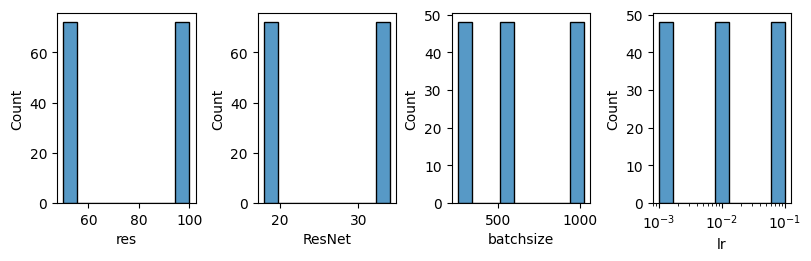

In [6]:
#Check that everything is ok with the files
fig, axs = plt.subplots(nrows = 1, ncols = len(hyperparams), figsize=(2*len(hyperparams), 2.5), layout="constrained")
for i, param in enumerate(hyperparams):
    if param=="lr":
        sn.histplot(results_df, x=param, ax = axs[i], log_scale=True)
        axs[i].set_xscale("log")
    else:
        sn.histplot(results_df, x=param, ax = axs[i])

<AxesSubplot: >

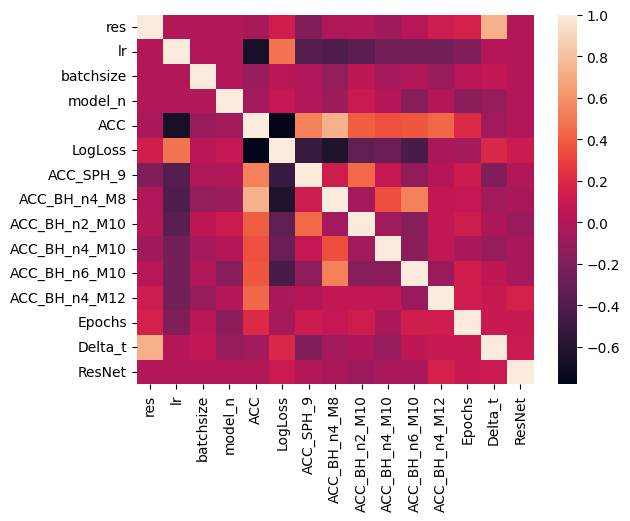

In [7]:
sn.heatmap(results_df.corr())

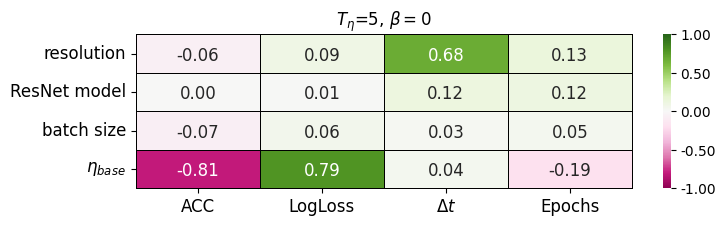

In [8]:
fig, ax = plt.subplots(1,1, figsize=(8, len(hyperparams.keys())*0.5))
results_1 = results_df[col_order_1].corr(method="spearman")
sn.heatmap(results_1.loc[hyperparams.keys(), metrics], cmap="PiYG", annot=True, 
            linewidth=0.5,
            linecolor='black',
            clip_on=False,
            fmt='.2f', 
            annot_kws={"va": 'center_baseline', "size": 12},
            vmin=-1,
            vmax=1,
            cbar = True,
            cbar_kws={'format': '%.2f'}, ax=ax)
ax.xaxis.set_ticklabels(metric_labels, size=12, rotation=0)
ax.yaxis.set_ticklabels(hyperparams_1_labels, size=12, rotation=0)
ax.set_title(r"$T_{\eta}$=5, $\beta=0$", size=12)
fig.savefig(f"../results/resnet_hyperparams/resnet_hyperparam_corrs_1.pdf", format="pdf",bbox_inches='tight')

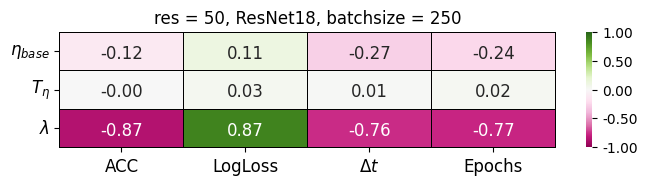

In [12]:
fig, ax = plt.subplots(1,1, figsize=(8, len(hyperparams_2)*0.5))
results_1 = lr_results_df[col_order_2].corr(method="spearman")
sn.heatmap(results_1.loc[hyperparams_2.keys(), metrics], cmap="PiYG", annot=True, 
            linewidth=0.5,
            linecolor='black',
            clip_on=False,
            fmt='.2f', 
            annot_kws={"va": 'center_baseline', "size": 12},
            vmin=-1,
            vmax=1,
            cbar = True,
            cbar_kws={'format': '%.2f'}, ax=ax)
ax.xaxis.set_ticklabels(metric_labels, size=12, rotation=0)
ax.yaxis.set_ticklabels(hyperparams_2_labels, size=12, rotation=0)
ax.set_title(f"res = 50, ResNet18, batchsize = 250", size=12)
fig.savefig(f"../results/resnet_hyperparams/resnet_hyperparam_corrs_2.pdf", format="pdf",bbox_inches='tight')

<AxesSubplot: >

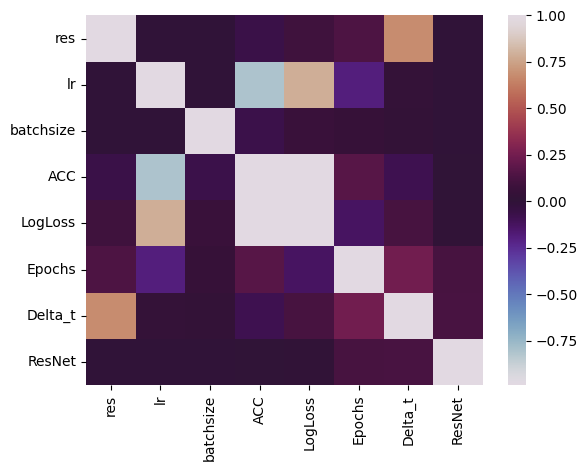

In [13]:
sn.heatmap(results_df.drop(columns=["ACC_SPH_9", "ACC_BH_n4_M8", "ACC_BH_n2_M10", "ACC_BH_n4_M10", 
                                    "ACC_BH_n6_M10", "ACC_BH_n4_M12", "model_n"]).corr(method="spearman"), cmap="twilight")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


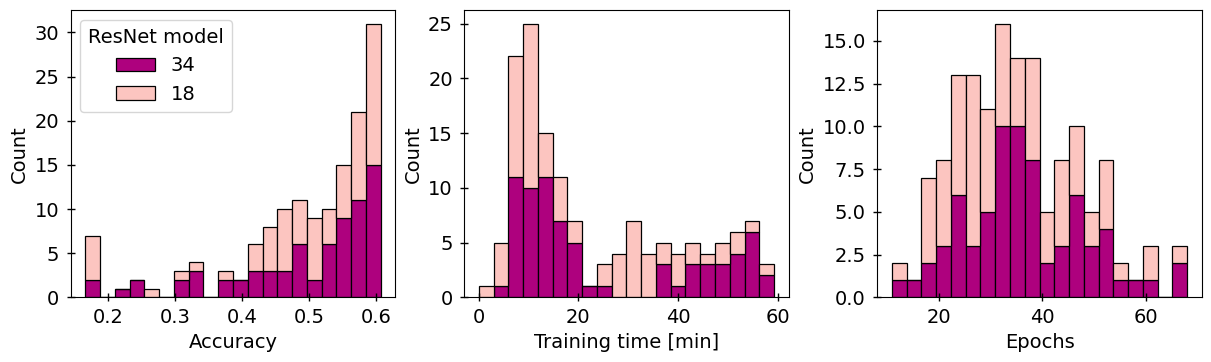

In [14]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize=(12, 3.5), layout="constrained")

sn.histplot(results_df, x="ACC", hue="ResNet", ax=axs[0], bins=20, palette=["#fcc5c0", "#ae017e"], alpha=1, multiple='stack')
axs[0].set_xlabel("Accuracy", fontsize=14)
axs[0].set_ylabel("Count", fontsize=14)
axs[0].legend(title="ResNet model", labels=[34, 18], fontsize=14, title_fontsize=14)

sn.histplot(results_df, x="Delta_t", hue="ResNet", ax=axs[1], bins=20, palette=["#fcc5c0", "#ae017e"], alpha=1, multiple='stack')
axs[1].set_xlabel("Training time [min]", fontsize=14)
axs[1].legend().remove()
axs[1].set_ylabel("Count", fontsize=14)
sn.histplot(results_df, x="Epochs", hue="ResNet", ax=axs[2], bins=20, palette=["#fcc5c0", "#ae017e"], alpha=1, multiple='stack')
axs[2].set_xlabel("Epochs", fontsize=14)
axs[2].legend().remove()
axs[2].set_ylabel("Count", fontsize=14)

for ax in axs:
    ax.tick_params(which="both", direction="inout", bottom=True, left=True, labelsize=14, pad=5, length=4, width=1)
    ax.tick_params(which="major", length=6)
fig.savefig(f"../results/resnet_hyperparams/resnet_hyperparam_resnetmodel.pdf", format="pdf",bbox_inches='tight')

In [15]:
print(results_df[results_df["ResNet"]==18]["Delta_t"].mean(), results_df[results_df["ResNet"]==18]["Delta_t"].std())
print(results_df[results_df["ResNet"]==34]["Delta_t"].mean(), results_df[results_df["ResNet"]==34]["Delta_t"].std())
print(results_df[results_df["ResNet"]==18]["ACC"].mean(), results_df[results_df["ResNet"]==18]["ACC"].std())
print(results_df[results_df["ResNet"]==34]["ACC"].mean(), results_df[results_df["ResNet"]==34]["ACC"].std())
print(results_df[results_df["ResNet"]==18]["Epochs"].mean(), results_df[results_df["ResNet"]==18]["Epochs"].std())
print(results_df[results_df["ResNet"]==34]["Epochs"].mean(), results_df[results_df["ResNet"]==34]["Epochs"].std())

21.762500000000003 15.200512106829137
25.27388888888889 18.14308695844912
0.4930416666666666 0.1155867929632496
0.4931844135802469 0.11247781860825838
34.18055555555556 11.813487623384384
36.56944444444444 11.836713462887571


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


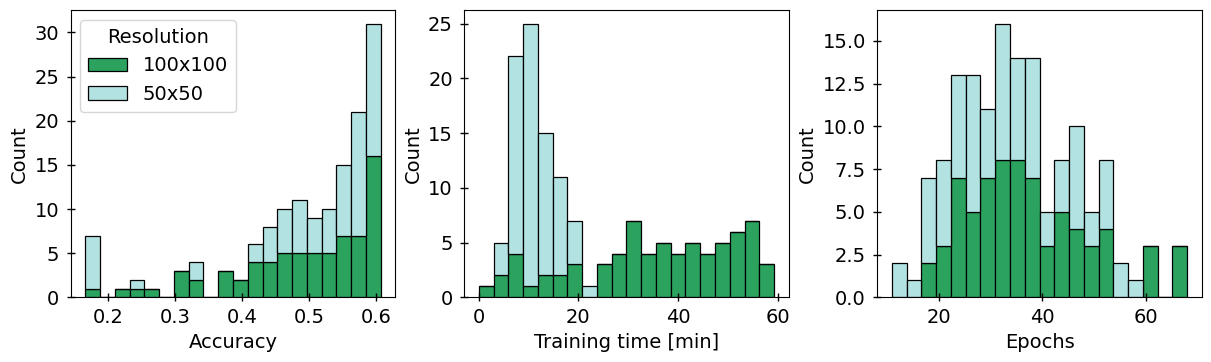

In [16]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize=(12, 3.5), layout="constrained")

sn.histplot(results_df, x="ACC", hue="res", ax=axs[0], bins=20, palette=["#b2e2e2", "#2ca25f"], alpha=1, multiple='stack')
axs[0].set_xlabel("Accuracy", fontsize=14)
axs[0].set_ylabel("Count", fontsize=14)
axs[0].legend(title="Resolution", labels=["100x100", "50x50"], fontsize=14, title_fontsize=14)
sn.histplot(results_df, x="Delta_t", hue="res", ax=axs[1], bins=20, palette=["#b2e2e2", "#2ca25f"], alpha=1, multiple='stack')
axs[1].set_xlabel("Training time [min]", fontsize=14)
axs[1].legend().remove()
axs[1].set_ylabel("Count", fontsize=14)
sn.histplot(results_df, x="Epochs", hue="res", ax=axs[2], bins=20, palette=["#b2e2e2", "#2ca25f"], alpha=1, multiple='stack')
axs[2].set_xlabel("Epochs", fontsize=14)
axs[2].legend().remove()
axs[2].set_ylabel("Count", fontsize=14)

for ax in axs:
    ax.tick_params(which="both", direction="inout", bottom=True, left=True, labelsize=14, pad=5, length=4, width=1)
    ax.tick_params(which="major", length=6)
fig.savefig(f"../results/resnet_hyperparams/resnet_hyperparam_resolution.pdf", format="pdf",bbox_inches='tight')

In [17]:
print(results_df[results_df["res"]==50]["Delta_t"].mean(), results_df[results_df["res"]==50]["Delta_t"].std())
print(results_df[results_df["res"]==100]["Delta_t"].mean(), results_df[results_df["res"]==100]["Delta_t"].std())
print(results_df[results_df["res"]==50]["ACC"].mean(), results_df[results_df["res"]==50]["ACC"].std())
print(results_df[results_df["res"]==100]["ACC"].mean(), results_df[results_df["res"]==100]["ACC"].std())

11.371805555555556 4.086980815591255
35.66458333333333 15.828773847461607
0.4968533950617284 0.12209731321965195
0.4893726851851852 0.10523995543975478


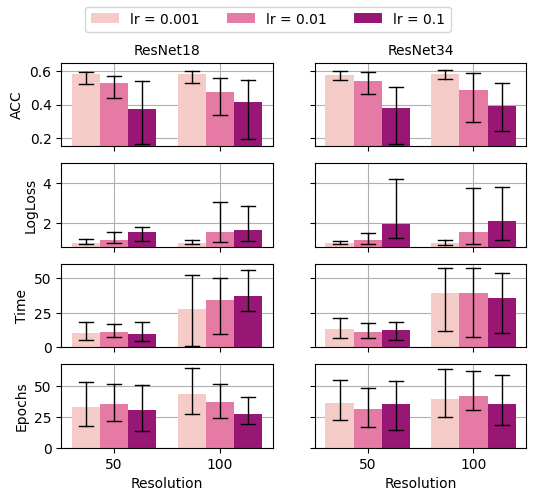

In [18]:

key = "ResNet"
hue_key = "lr"
hue_palette=["#fcc5c0", "#f768a1", "#ae017e", "grey"][0:3]
fig, axs = plt.subplots(nrows = len(metrics), ncols = len(hyperparams[key]), sharex=True, sharey="row", 
                        figsize=(3*len(hyperparams[key]), 2.5*len(val_metrics)))
for j in range(len(metrics)):
    metric_key = metrics[j]
    for i in range(len(hyperparams[key])):
        value = hyperparams[key][i]
        axs[0][i].set_title(f"ResNet{value}", fontsize=10)
        df_subset = results_df[results_df[key] == value]
        sn.barplot(df_subset, x="res", y=metric_key, ax=axs[j][i], hue = hue_key,
                                    errorbar=("pi", 95), capsize=.4, err_kws={"color": "black", "linewidth": 1},
                                    palette=hue_palette) 
    if metric_key == "ACC":
        for ax in axs[j]:
            ax.set_ylim(0.15, 0.65)
    elif metric_key == "LogLoss":
        for ax in axs[j]:
            ax.set_ylim(0.8, 5)
    elif metric_key == "n_trees":
        for ax in axs[j]:
            ax.set_ylabel("N trees")
            ax.set_yscale("log")
    elif metric_key == "Delta_t":
        for ax in axs[j]:
            ax.set_ylabel("Time")

    
fig.suptitle(f"      ", x=0.1, va="top", fontsize=20)
handles, labels = axs[0][0].get_legend_handles_labels()
labels = [fr"{hue_key} = {label}" for label in labels]
fig.legend(handles, labels, loc='upper center', ncol=4, labelspacing=0.1, fontsize=10)

for ax in axs.flatten():
    ax.set_xlabel("Resolution")
    if ax.get_legend() != None:
        ax.get_legend().remove()
    ax.set_axisbelow(True)
    ax.grid(True)
#fig.savefig(f"../results/xgboost_hyperparams/XGBoost_high_level_gridsearch.pdf", format="pdf", bbox_inches='tight', dpi=350)

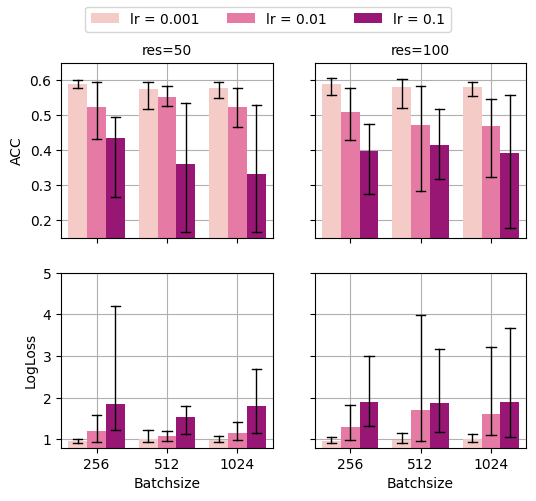

In [19]:

key = "res"
hue_key = "lr"
hue_palette=["#fcc5c0", "#f768a1", "#ae017e", "grey"][0:3]
fig, axs = plt.subplots(nrows = len(val_metrics), ncols = len(hyperparams[key]), sharex=True, sharey="row", 
                        figsize=(3*len(hyperparams[key]), 2.5*len(val_metrics)))
for j in range(len(val_metrics)):
    metric_key = val_metrics[j]
    for i in range(len(hyperparams[key])):
        value = hyperparams[key][i]
        axs[0][i].set_title(f"res={value}", fontsize=10)
        df_subset = results_df[results_df[key] == value]
        sn.barplot(df_subset, x="batchsize", y=metric_key, ax=axs[j][i], hue = hue_key,
                                    errorbar=("pi", 95), capsize=.4, err_kws={"color": "black", "linewidth": 1},
                                    palette=hue_palette) 
    if metric_key == "ACC":
        for ax in axs[j]:
            ax.set_ylim(0.15, 0.65)
    elif metric_key == "LogLoss":
        for ax in axs[j]:
            ax.set_ylim(0.8, 5)
    elif metric_key == "n_trees":
        for ax in axs[j]:
            ax.set_ylabel("N trees")
            ax.set_yscale("log")
    elif metric_key == "Delta_t":
        for ax in axs[j]:
            ax.set_ylabel("Time")
            ax.set_yscale("log")
    
fig.suptitle(f"      ", x=0.1, va="top", fontsize=20)
handles, labels = axs[0][0].get_legend_handles_labels()
labels = [fr"{hue_key} = {label}" for label in labels]
fig.legend(handles, labels, loc='upper center', ncol=4, labelspacing=0.1, fontsize=10)

for ax in axs.flatten():
    ax.set_xlabel("Batchsize")
    if ax.get_legend() != None:
        ax.get_legend().remove()
    ax.set_axisbelow(True)
    ax.grid(True)
#fig.savefig(f"../results/xgboost_hyperparams/XGBoost_high_level_gridsearch.pdf", format="pdf", bbox_inches='tight', dpi=350)

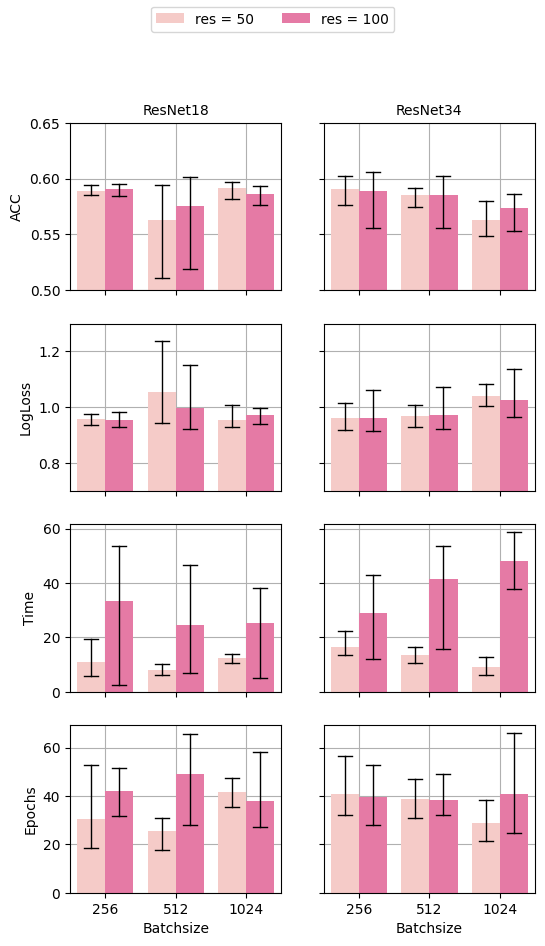

In [20]:

key = "ResNet"
hue_key = "res"
hue_palette=["#fcc5c0", "#f768a1", "#ae017e", "grey"][0:2]
fig, axs = plt.subplots(nrows = len(metrics), ncols = len(hyperparams[key]), sharex=True, sharey="row", 
                        figsize=(3*len(hyperparams[key]), 2.5*len(metrics)))
for j in range(len(metrics)):
    metric_key = metrics[j]
    for i in range(len(hyperparams[key])):
        value = hyperparams[key][i]
        axs[0][i].set_title(f"ResNet{value}", fontsize=10)
        df_subset = results_df[results_df[key] == value]
        df_subset = df_subset[df_subset["lr"] == 0.001]
        sn.barplot(df_subset, x="batchsize", y=metric_key, ax=axs[j][i], hue = hue_key,
                                    errorbar=("pi", 95), capsize=.4, err_kws={"color": "black", "linewidth": 1},
                                    palette=hue_palette) 
    if metric_key == "ACC":
        for ax in axs[j]:
            ax.set_ylim(0.5, 0.65)
    elif metric_key == "LogLoss":
        for ax in axs[j]:
            ax.set_ylim(0.7, 1.3)
    elif metric_key == "n_trees":
        for ax in axs[j]:
            ax.set_ylabel("N trees")
            ax.set_yscale("log")
    elif metric_key == "Delta_t":
        for ax in axs[j]:
            ax.set_ylabel("Time")

    
fig.suptitle(f"      ", x=0.1, va="top", fontsize=20)
handles, labels = axs[0][0].get_legend_handles_labels()
labels = [fr"{hue_key} = {label}" for label in labels]
fig.legend(handles, labels, loc='upper center', ncol=4, labelspacing=0.1, fontsize=10)

for ax in axs.flatten():
    ax.set_xlabel("Batchsize")
    if ax.get_legend() != None:
        ax.get_legend().remove()
    ax.set_axisbelow(True)
    ax.grid(True)
#fig.savefig(f"../results/xgboost_hyperparams/XGBoost_high_level_gridsearch.pdf", format="pdf", bbox_inches='tight', dpi=350)

In [21]:
hyperparams_2

{'lr': [0.0001, 0.001], 'cycle_T': [5, 50, 500], 'weight_decay': [0, 0.1]}

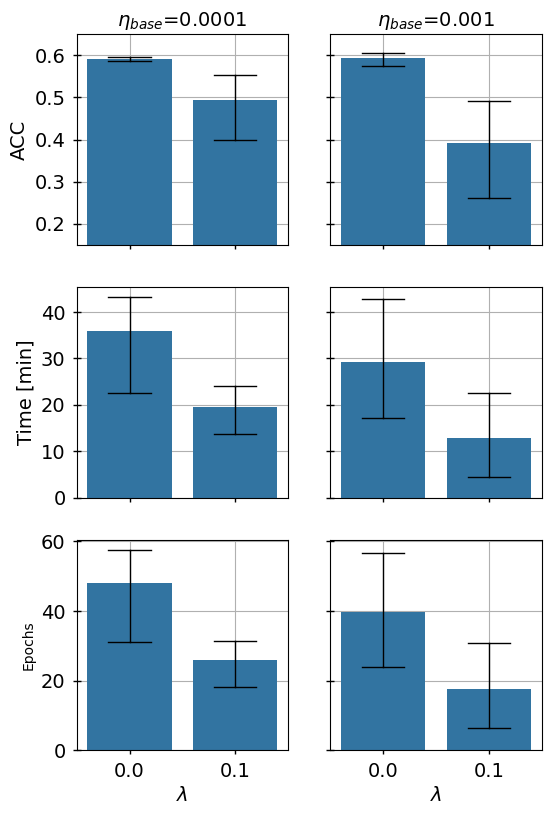

In [22]:

key = "lr"
plot_metrics = ["ACC", "Delta_t", "Epochs"]
fig, axs = plt.subplots(nrows = len(plot_metrics), ncols = len(hyperparams_2[key]), sharex=True, sharey="row", 
                        figsize=(3*len(hyperparams_2[key]), 3.1*len(plot_metrics)))
for j in range(len(plot_metrics)):
    metric_key = plot_metrics[j]
    for i in range(len(hyperparams_2[key])):
        value = hyperparams_2[key][i]
        axs[0][i].set_title(str(r"$\eta_{base}$"+f"={value}"), fontsize=14)
        df_subset = lr_results_df[lr_results_df[key] == value]
        sn.barplot(df_subset, x="weight_decay", y=metric_key, ax=axs[j][i],
                                    errorbar=("pi", 95), capsize=.4, err_kws={"color": "black", "linewidth": 1}) 
    if metric_key == "ACC":
        for ax in axs[j]:
            ax.set_ylabel("ACC", fontsize=14)
            ax.set_ylim(0.15, 0.65)
    elif metric_key == "LogLoss":
        for ax in axs[j]:
            ax.set_ylabel("LogLoss", fontsize=14)
            ax.set_ylim(0.8, 2.2)
    elif metric_key == "n_trees":
        for ax in axs[j]:
            ax.set_ylabel("N trees", fontsize=14)
            #ax.set_yscale("log")
    elif metric_key == "Delta_t":
        for ax in axs[j]:
            ax.set_ylabel("Time [min]", fontsize=14)
            #ax.set_yscale("log")

for ax in axs.flatten():
    #ax.set_xlabel(r"$N_\text{train}$")
    if ax.get_legend() != None:
        ax.get_legend().remove()
    ax.set_axisbelow(True)
    ax.grid(True)
    ax.tick_params(which="both", direction="inout", bottom=True, left=True, labelsize=14, pad=5, length=4, width=1)
    ax.tick_params(which="major", length=6)
    ax.set_xlabel(r"$\lambda$", fontsize=14)
fig.savefig(f"../results/resnet_hyperparams/resnet_hyperparams_lr_wd.pdf", format="pdf", bbox_inches='tight', dpi=350)

In [23]:
#SCatterplot deluxe
lr_results_df["Category"] = 1
mask_1 = lr_results_df[(lr_results_df["lr"] == 0.001) & (lr_results_df["weight_decay"] == 0)].index
lr_results_df.loc[mask_1, "Category"] = 2
mask_2 = lr_results_df[(lr_results_df["lr"] == 0.0001) & (lr_results_df["weight_decay"] == 0.1)].index
lr_results_df.loc[mask_2, "Category"] = 3
mask_3 = lr_results_df[(lr_results_df["lr"] == 0.001) & (lr_results_df["weight_decay"] == 0.1)].index
lr_results_df.loc[mask_3, "Category"] = 4


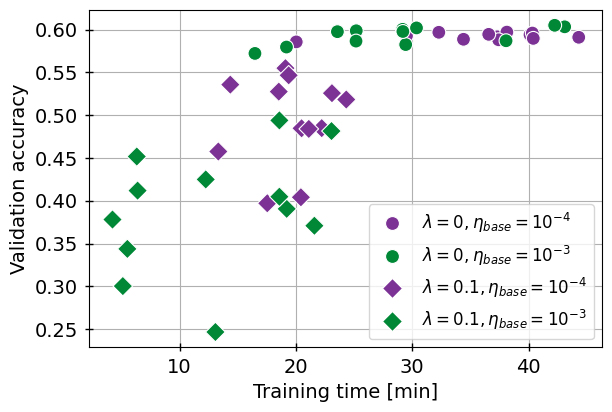

In [39]:
fig, ax = plt.subplots(nrows =1, ncols = 1, layout="constrained", figsize=(6,4))
hue_palette=["#7b3294", "#008837", "#7b3294", "#008837"]
markers = ["o", "o", "D", "D"]
sn.scatterplot(lr_results_df, x="Delta_t", y="ACC", style="Category", hue="Category", palette=hue_palette, markers=markers, ax=ax, s=100)
handles, labels = ax.get_legend_handles_labels()
labels = [r"$\lambda=0, \eta_{base}=10^{-4}$", r"$\lambda=0, \eta_{base}=10^{-3}$", r"$\lambda=0.1, \eta_{base}=10^{-4}$", r"$\lambda=0.1, \eta_{base}=10^{-3}$"]

ax.legend(handles=handles, labels=labels, fontsize=12)
ax.set_axisbelow(True)
ax.grid(True)
ax.tick_params(which="both", direction="inout", bottom=True, left=True, labelsize=14, pad=5, length=4, width=1)
ax.tick_params(which="major", length=6)
ax.set_xlabel(r"Training time [min]", fontsize=14)
ax.set_ylabel(r"Validation accuracy", fontsize=14)
fig.savefig(f"../results/resnet_hyperparams/resnet_hyperparams_lr_wd_scatter.pdf", format="pdf", bbox_inches='tight', dpi=350)